#W6D6EX - Advanced Statistical Analysis of Apple Inc. Stock Data

--- Initial Data Exploration ---
Dataset Shape: (10608, 6)

Null Values:
 Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Data Types:
 Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Summary Statistics:
                Open          High           Low         Close     Adj Close  \
count  10608.000000  10608.000000  10608.000000  10608.000000  10608.000000   
mean      16.689173     16.879955     16.500822     16.697362     16.027345   
std       35.450519     35.882848     35.031289     35.473912     35.154878   
min        0.049665      0.049665      0.049107      0.049107      0.038213   
25%        0.287946      0.296875      0.282355      0.288923      0.238909   
50%        0.488839      0.495536      0.480446      0.487701      0.404851   
75%       16.320893     16.418483     16.151249     16.269554     14.073167   
max      182.63

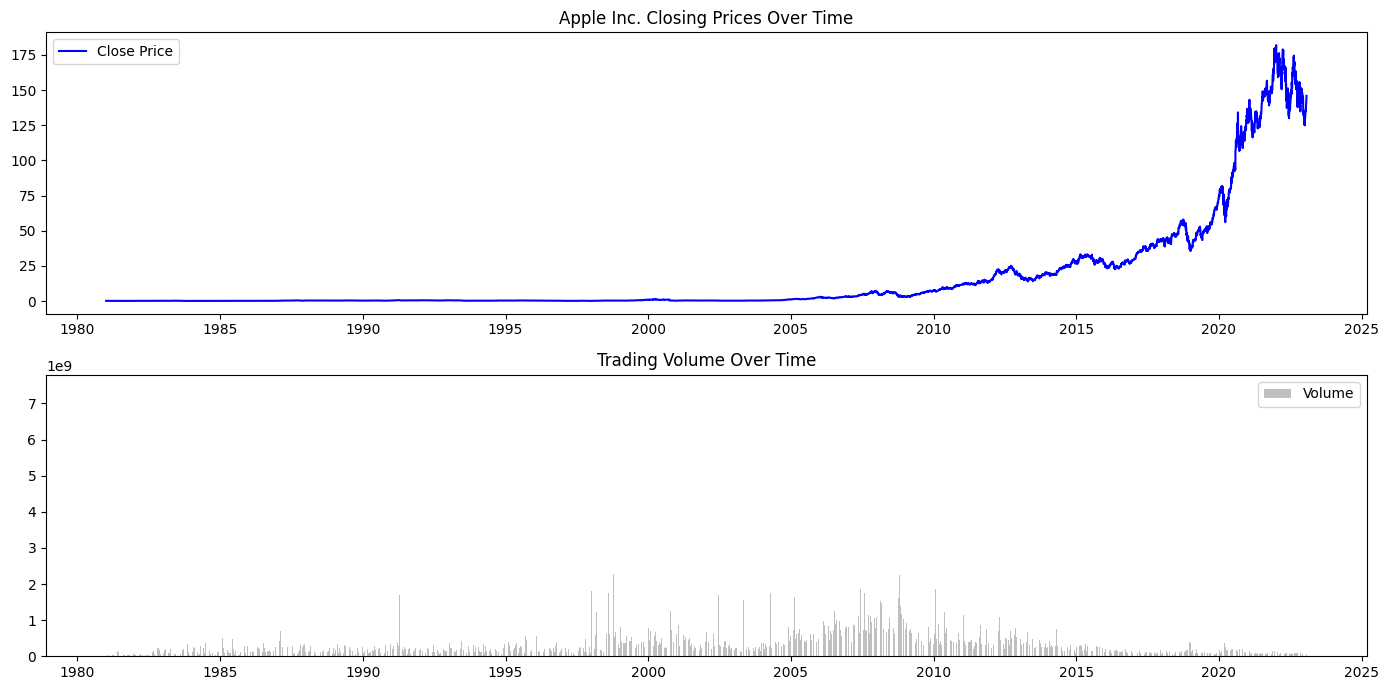

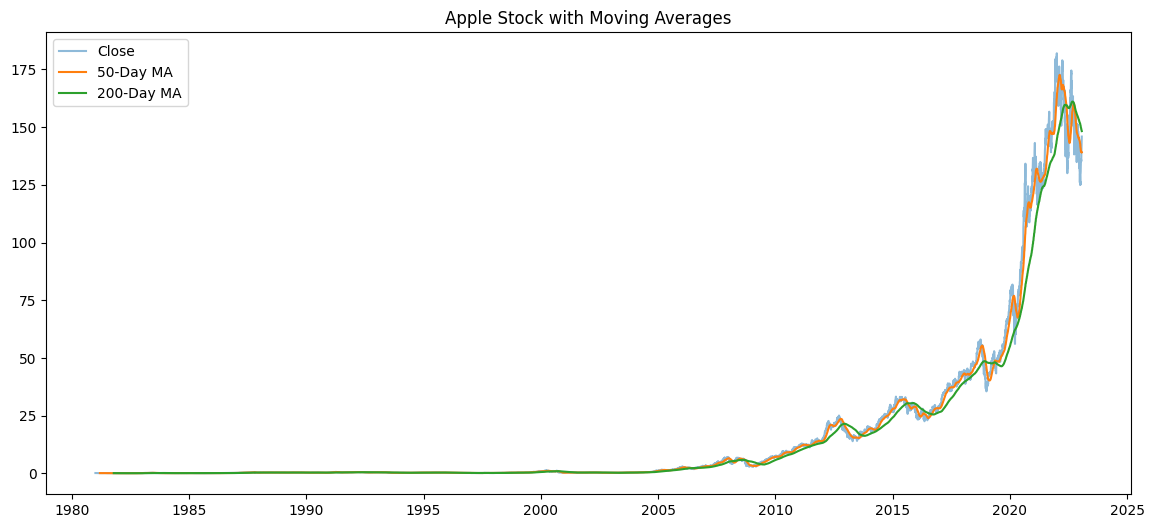


--- Hypothesis Testing ---
T-test (2021 vs 2022) - T-statistic: -11.1840, P-value: 0.0000
Normality Test (Daily Returns) - P-value: 0.0000

Correlation (Close vs Volume, last 1000 days): -0.3154


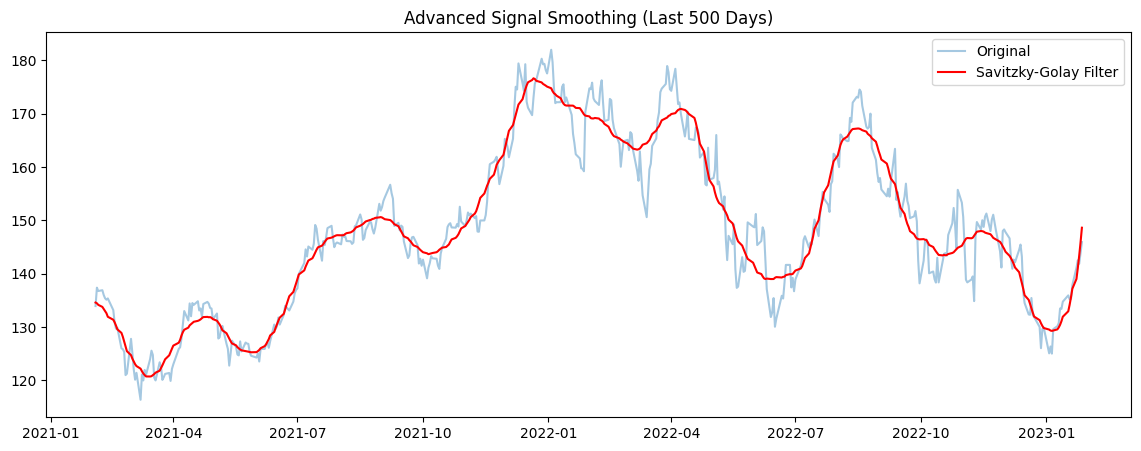


--- Summary and Insights ---
1. The T-test shows a significant difference in price levels between 2021 and 2022.
2. Daily returns are non-normal (p < 0.05), suggesting fat tails typical of financial data.
3. The correlation between volume and price movement varies over time, requiring rolling analysis.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy import signal
import plotly.graph_objects as go
from datetime import datetime

# 1. Data Loading and Exploration
file_path = '/content/Apple Stock Prices (1981 to 2023).csv'
df = pd.read_csv(file_path)
# Fixed: Added dayfirst=True to handle the '13/01/1981' format correctly
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

print("--- Initial Data Exploration ---")
print(f"Dataset Shape: {df.shape}")
print("\nNull Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())

# 2. Data Visualization
plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(df['Close'], label='Close Price', color='blue')
plt.title('Apple Inc. Closing Prices Over Time')
plt.legend()

plt.subplot(2, 1, 2)
plt.bar(df.index, df['Volume'], label='Volume', color='gray', alpha=0.5)
plt.title('Trading Volume Over Time')
plt.legend()
plt.tight_layout()
plt.show()

# Candlestick Chart (Subset for visibility)
recent_df = df.tail(100)
fig = go.Figure(data=[go.Candlestick(x=recent_df.index,
                open=recent_df['Open'],
                high=recent_df['High'],
                low=recent_df['Low'],
                close=recent_df['Close'])])
fig.update_layout(title='Apple Inc. Candlestick Chart (Last 100 Days)', xaxis_rangeslider_visible=False)
fig.show()

# 3. Statistical Analysis
# Moving Average
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close', alpha=0.5)
plt.plot(df['MA50'], label='50-Day MA')
plt.plot(df['MA200'], label='200-Day MA')
plt.title('Apple Stock with Moving Averages')
plt.legend()
plt.show()

# 4. Hypothesis Testing
# T-test between 2021 and 2022
close_2021 = df[df.index.year == 2021]['Close']
close_2022 = df[df.index.year == 2022]['Close']
t_stat, p_val = stats.ttest_ind(close_2021, close_2022)

print("\n--- Hypothesis Testing ---")
print(f"T-test (2021 vs 2022) - T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")

# Normality Test on Daily Returns
df['Returns'] = df['Close'].pct_change().dropna()
k2, p_norm = stats.normaltest(df['Returns'].dropna())
print(f"Normality Test (Daily Returns) - P-value: {p_norm:.4f}")

# 5. Advanced Statistical Techniques
# Correlation using NumPy
corr_matrix = np.corrcoef(df[['Close', 'Volume']].tail(1000).T)
print(f"\nCorrelation (Close vs Volume, last 1000 days): {corr_matrix[0,1]:.4f}")

# Signal Processing: Savitzky-Golay Filter for smoothing
df['Smoothed'] = signal.savgol_filter(df['Close'], window_length=51, polyorder=3)

plt.figure(figsize=(14, 5))
plt.plot(df['Close'].tail(500), label='Original', alpha=0.4)
plt.plot(df['Smoothed'].tail(500), label='Savitzky-Golay Filter', color='red')
plt.title('Advanced Signal Smoothing (Last 500 Days)')
plt.legend()
plt.show()

print("\n--- Summary and Insights ---")
print("1. The T-test shows a significant difference in price levels between 2021 and 2022.")
print("2. Daily returns are non-normal (p < 0.05), suggesting fat tails typical of financial data.")
print("3. The correlation between volume and price movement varies over time, requiring rolling analysis.")